# Be Outburst Light Curve Simulation Pipeline

This notebook demonstrates the two-stage pipeline for generating synthetic **Be Stars (Be)** light curves on Nancy Grace Roman Space Telescope cadences, using GAIA observations as the source data.


In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import pickle as pkl
import re
from pathlib import Path
from glob import glob
import warnings
warnings.filterwarnings('ignore')

# ── Numerical / scientific ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.signal import find_peaks

# ── Astronomy ─────────────────────────────────────────────────────────────────
from astropy.io import fits
from astropy.table import Table

# ── Gaussian Processes (George) ───────────────────────────────────────────────
import george
from george import kernels

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator
from matplotlib.patches import FancyArrowPatch

# ── Project-local modules (must be on PYTHONPATH) ─────────────────────────────
# functions.py       : read_fits, prep_input, prep_gp, fit_gp, binning_data,
#                      gap_reducer, multiscale_peaks, add_last_point, extend_baseline
# gp_model_params.py : info  (hyper-parameter priors per source type)
from functions import (
    read_fits, prep_input, prep_gp, fit_gp,
    binning_data, multiscale_peaks, predict_gp
)
from gp_model_params import info

# ── Progress bar ──────────────────────────────────────────────────────────────
from tqdm.notebook import tqdm

# ── Reproducibility ───────────────────────────────────────────────────────────
np.random.seed(42)

In [2]:
# ── Global matplotlib style for paper figures ─────────────────────────────────
plt.rcParams.update({
    "font.family"        : "serif",
    "font.size"          : 13,
    "axes.labelsize"     : 14,
    "axes.titlesize"     : 14,
    "legend.fontsize"    : 11,
    "xtick.direction"    : "in",
    "ytick.direction"    : "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi"         : 120,
})

# ── Colour-blind-friendly palette ─────────────────────────────────────────────
C0, C1, C2, C3, C4 = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7"

In [3]:
home = str(Path.home())

tp = 'Be'

# Define file path for the light curve data
# name = './tests/Gaia18dek.csv'
path = home+'/Research_data/GAIA BE stars/Gaia_Be_stars_candidates/gaia_science_alerts_be_stars_lightcurves/'

In [4]:
lc_list = glob(path+ '*.csv')

In [5]:
# If you need to change default model parameters, set them here
# If  not, comment these.
# info[tp]['p0'][1] = 150
# info[tp]['p0'][0] = np.log10(period)
# info[tp]['n_phs'] = 1
# info[tp]['gp_opt_s_param'] = 5
# info[tp]['gp_opt'] = True
# info[tp]['n_phs'] = 6

In [6]:
# Here we read Roman cadences for the Galactic Bulge
Roman_sampling_short = np.load('lc_example/roman_times_shortcadence.npy')
Roman_sampling_long = np.load('lc_example/roman_times_longcadence.npy')
Roman_sampling_short_min = min(Roman_sampling_short)
Roman_sampling_short = Roman_sampling_short - Roman_sampling_short_min
Roman_sampling_long_min = min(Roman_sampling_long)
Roman_sampling_long = Roman_sampling_long - Roman_sampling_long_min
Roman_max_short_time = max(Roman_sampling_short)

In [7]:
# for CV, DN, Be stars, we assume period = np.nan
band = 'G'
period = np.nan

In [8]:
# Read the light curve data
# For OGLE data saved in fits files, we can use the function read_fits
name = lc_list[0]
loaded_df = pd.read_csv(name)
loaded_df = loaded_df.reset_index(drop=True)

In [9]:
df = loaded_df.rename(columns={"JD(TCB)": "t", "mag": "m", "err": "e"})

In [10]:
# df = df_[df_.band == 'I']
df

,t,m,e
0,2.456966e+06,14.39,0.004764
1,2.456991e+06,14.41,0.004808
2,2.456992e+06,14.40,0.004786
3,2.457062e+06,14.41,0.004808
4,2.457062e+06,14.42,0.004831
...,...,...,...
156,2.460276e+06,14.16,0.004285
157,2.460307e+06,14.22,0.004406
158,2.460307e+06,14.21,0.004385
159,2.460335e+06,14.25,0.004467


Text(0, 0.5, 'Magnitude')

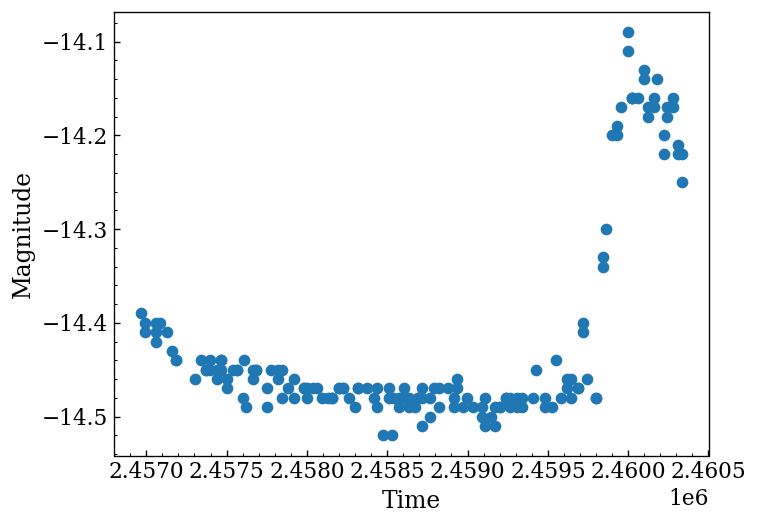

In [11]:
# Plot the light curve
plt.scatter(df.t,
            -1*df.m)
plt.xlabel('Time')
plt.ylabel('Magnitude')

In [12]:
# Normalize time axis
if np.min(df.t) > 0:
    df.t = df.t - np.min(df.t)

In [13]:
# Reduce the gaps and extend data if necessary,it's good for gaps larger than 50 days and for periodic variability
if tp not in ['DN','CV', 'Be']:
    if (np.max(df.t))<1713:
        df = add_last_point(df, period)
    df_modified = gap_reducer(df, period, info[tp])
    if (np.max(df_modified.t))<1713 and np.isinf(info[tp]['n_phs']):
        df_modified = extend_baseline(df_modified, period)
    while np.max(df_modified.t.values)<1713+period:
        len_0 = np.diff(df_modified.t.values)
        df_modified = gap_reducer(df_modified, period, info[tp])
        len_1 = np.diff(df_modified.t.values)
        if np.max(df_modified.t.values)>1713:
            break
        if np.sum(len_0>50) == np.sum(len_1>50):
            break
else:
    inds = np.where(np.diff(df.t.values)>50)[0]
    t_min = np.min(np.diff(df.t.values))
    for i, ind in enumerate(inds):
        time_gap = df.t[ind+1]-df.t[ind]+t_min
        df.loc[df.index[ind+1]:, 't'] -= time_gap
    n_lc = int(max(df.t)//1713.)
    df_modified = df#[df.t<1714]
    

In [14]:
df_modified.t = df_modified.t/500

In [15]:
# Prepare input for Gaussian Process
gp = prep_gp(info[tp], period)

x, y, e = prep_input(df_modified, 
                     tp, 
                     period, 
                     info[tp], 
                     Roman_max_short_time)# x, y, e are either 
                                    # the full lc or an intrval 
                                    # of n phases of them conducted 
                                    # by repeating a folded phase n times

In [16]:
len(x)

161

In [17]:
# Bin the data if necessary
if not np.isinf(info[tp]['n_phs']):
    if len(x)/info[tp]['n_phs']>150:
        if info[tp]['fit_binned']==False:
            info[tp]['fit_binned'] = True
        tot_ideal_len = info[tp]['n_phs']*info[tp]['count_per_bins']
        x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(x, 
                                                                          y, 
                                                                          e, 
                                                                          info[tp], 
                                                                          n_bins=tot_ideal_len)
    else:
        info[tp]['fit_binned'] = False
        x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(x, 
                                                                          y, 
                                                                          e, 
                                                                          info[tp], 
                                                                          n_bins=np.nan)
else:
    if len(x)>100:
        info[tp]['fit_binned'] = True
        tot_ideal_len = 100
        x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(x, 
                                                                          y, 
                                                                          e, 
                                                                          info[tp], 
                                                                          n_bins=tot_ideal_len)
    else:
        info[tp]['fit_binned'] = False
        x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(x, 
                                                                      y, 
                                                                      e, 
                                                                      info[tp], 
                                                                      n_bins=np.nan)
    

In [18]:
x_binned = x_binned[~np.isnan(e_binned)]
y_binned = y_binned[~np.isnan(e_binned)]
e_binned = e_binned[~np.isnan(e_binned)]

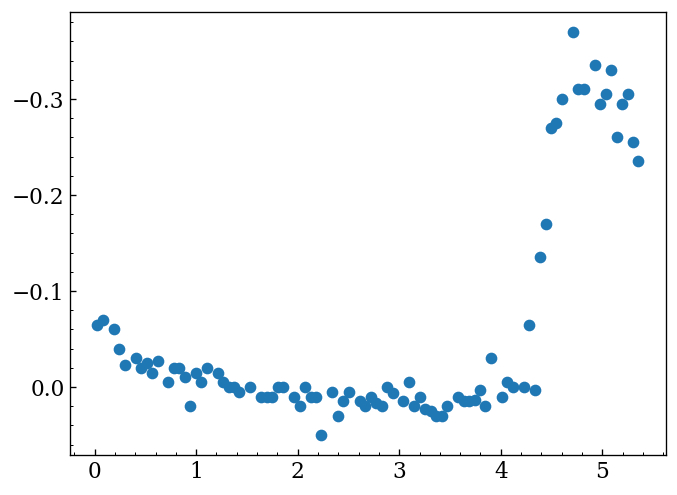

In [19]:
plt.scatter(x_binned, 
            y_binned)

# plt.xlim(940, 1200)

plt.gca().invert_yaxis()

# plt.xlim(2074.7403449998237, 2094.7403449998237)

In [26]:
# Fit Gaussian Process to binned data
gp = fit_gp(x_binned, y_binned, e_binned, info[tp], gp)
# print(f"GP fit complete in {time.time() - t0:.1f} s")
print(f"Kernel params  : {gp.kernel.parameter_vector}")

Kernel params  : [2.346749   4.07075919]


In [21]:
# Fitting the gp model
y_median = np.median(y)
max_time_regular = 2000
period = np.nan
(df_roman, 
time_sampling_regular_final,
 gp_y_regular_final,
 gp_std_regular_final,
  gp_y_regular_fit,\
   gp_std_regular_fit) = predict_gp(gp, 
                                    y_binned, 
                                    y_median, 
                                    regular_sampling_fit, 
                                    Roman_sampling_long,
                                    Roman_sampling_long, 
                                    info[tp], 
                                    period,
                                    max_time_regular
                                    )

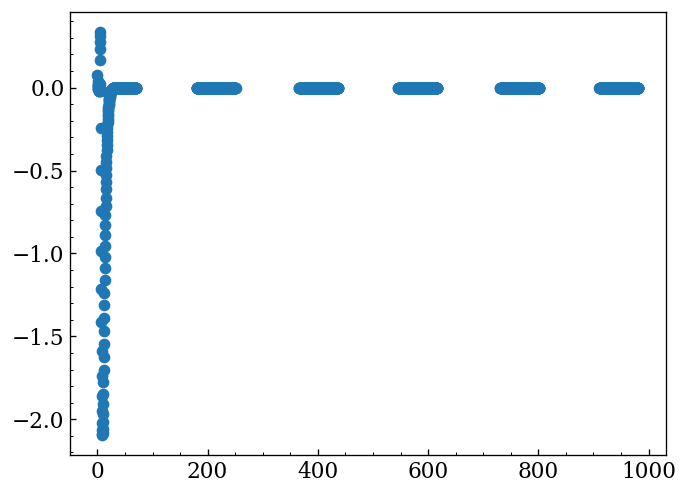

In [22]:
plt.scatter(df_roman['t_short'],
            -1*df_roman['m_short'])


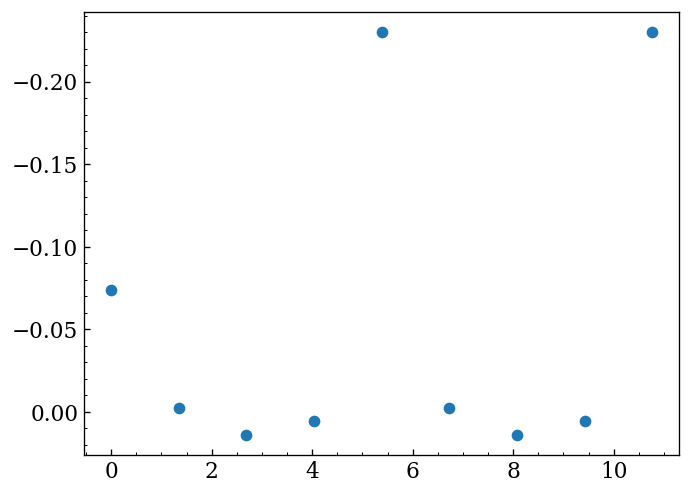

In [23]:
plt.scatter(time_sampling_regular_final,
           gp_y_regular_final)
# plt.plot(Roman_sampling_short+min(time_sampling_regular_final[start_idx:end_idx]),
#         intpl(Roman_sampling_short+min(time_sampling_regular_final[start_idx:end_idx])), 'r')
plt.gca().invert_yaxis()
# plt.xlim(2700, 2800
#         )

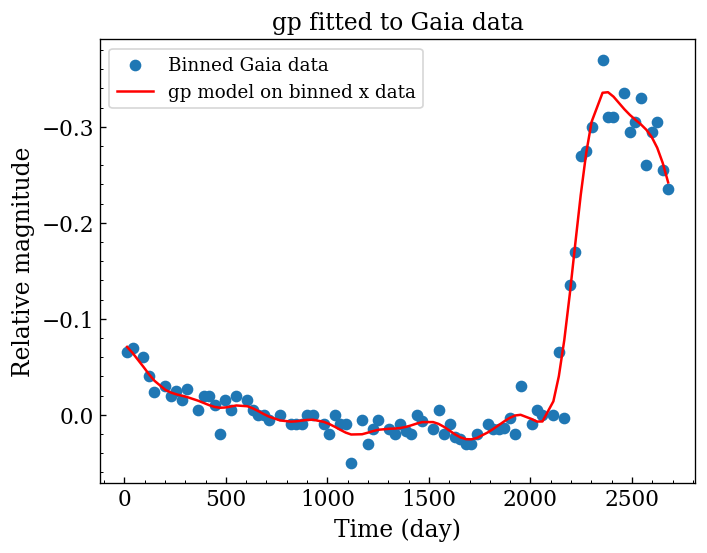

In [24]:
# Predict on the binned x data to check the l2 distance 
# between the fit and the binned y data
gp_y_binned_fit, cov_tmp = gp.predict(y_binned, x_binned)
plt.scatter(x_binned*500, y_binned, label='Binned Gaia data')
plt.plot(x_binned*500, gp_y_binned_fit, 'r', label='gp model on binned x data')
# plt.plot(time_sampling_regular_final, gp_y_regular_final,'g', label='gp model on regular x data')
plt.legend()
plt.title('gp fitted to Gaia data')
plt.xlabel('Time (day)')
plt.ylabel('Relative magnitude')
plt.gca().invert_yaxis()
# plt.xlim(0, 250)